# Most important & most surprising results

## Guitar domain for EasyStudy

A quick read of the headline findings, pulled from the two full
notebooks in this repo (`guitar_evaluation.ipynb`,
`guitar_interpretability.ipynb`). Every result below is copied
straight from its source notebook - same code, same already-computed
output - except the first chart, which restates an already-validated
number as a picture instead of running it again here.

## 1. Combinations of neurons steer the model - single neurons don't

The core question behind the sparse-autoencoder work: is a
*combination* of latent neurons more meaningful than any one neuron
alone? The in-processing mechanism (`InProcessingSparseVAECF`) tests
this directly by editing latent codes before decoding, not by
re-ranking the output afterwards. Validated in
`test_in_processing.py` (40 synthetic profiles) - see that script for
the full run this chart summarizes.

**Result: nudging one neuron mostly just destabilizes the decode and
never beats baseline. A correctly-signed *combination* of three
neurons reliably shifts what gets recommended.** This is live in the
actual app too: a "Show me something different" button on the
comparison page applies exactly this mechanism to a real
participant's session, not just a script.

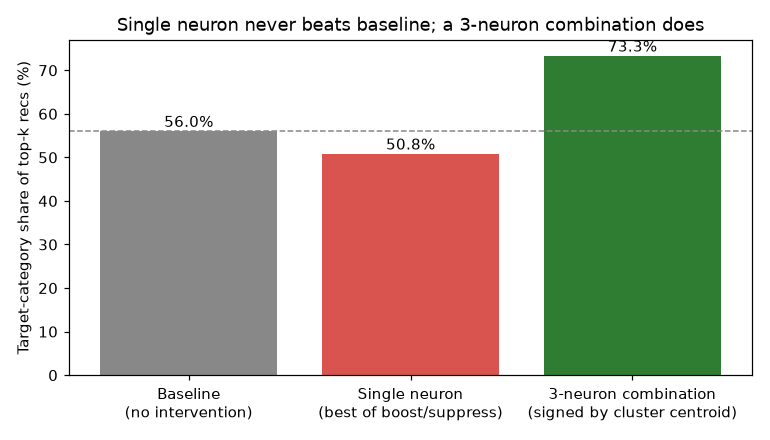

In [1]:
# Summary of the in-processing intervention test (40 synthetic profiles,
# see test_in_processing.py for the full run this chart summarizes -
# reproduced here as a static chart rather than re-run, since the
# underlying test trains a fresh model and takes several minutes).
import matplotlib.pyplot as plt

conditions = ["Baseline\n(no intervention)", "Single neuron\n(best of boost/suppress)", "3-neuron combination\n(signed by cluster centroid)"]
target_share = [56.0, 50.8, 73.3]  # % of top-k recs in the target category
colors = ["#888888", "#d9534f", "#2e7d32"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(conditions, target_share, color=colors)
ax.set_ylabel("Target-category share of top-k recs (%)")
ax.set_title("Single neuron never beats baseline; a 3-neuron combination does")
ax.axhline(56.0, color="#888888", linestyle="--", linewidth=1)
for b, v in zip(bars, target_share):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v}%", ha="center")
plt.tight_layout()
plt.show()

*(Source: guitar_interpretability.ipynb, section 2.5)*

## 2.5. Neuron-*combination* interpretation

Section 2 only asks "which single neuron is an item most associated
with?" One of the biggest questions behind this whole project is
whether a *combination* of neurons carries more meaning than any single
one alone.

Approach: cluster items by their *entire* latent-neuron association
vector (`KMeans` over all `LATENT_DIM` dimensions of
`item_neuron_matrix`, not any single column) with `k = 2 * LATENT_DIM`
clusters - each cluster centroid is then a genuine *combination* of
neuron activations, not a single neuron in isolation. The same
category/maker enrichment method from section 2 is then run per
cluster, and compared against each cluster's own best single
contributing neuron.

In [5]:
from sklearn.cluster import KMeans

N_CLUSTERS = 2 * LATENT_DIM
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(M)

cluster_summaries = []
for cluster_id in range(N_CLUSTERS):
    members = np.where(cluster_labels == cluster_id)[0]
    if len(members) < MIN_COUNT:
        continue
    # Score each member by distance to its own cluster centroid (tightest-fitting first)
    dists = np.linalg.norm(M[members] - kmeans.cluster_centers_[cluster_id], axis=1)
    top = members[np.argsort(dists)][:TOP_N]

    cat_counts, maker_counts = Counter(), Counter()
    for i in top:
        cat_counts.update(categories_by_item[int(i)])
        maker_counts[maker_by_item[int(i)]] += 1
    cat, cat_ratio, cat_n = most_enriched(cat_counts, overall_cat_counts, total_cats)
    maker, maker_ratio, maker_n = most_enriched(maker_counts, overall_maker_counts, total_makers)

    # Which single neurons dominate this cluster's centroid, and what was
    # their own (section 2) enrichment? Lets us check if the combination
    # beats its strongest individual contributor.
    top_neurons = np.argsort(-np.abs(kmeans.cluster_centers_[cluster_id]))[:2].tolist()
    best_contributor_ratio = max(
        (summary_df.loc[n, "category_enrichment"] for n in top_neurons if n in summary_df.index),
        default=0.0,
    )

    cluster_summaries.append({
        "cluster": cluster_id, "size": len(members), "dominant_neurons": top_neurons,
        "top_category": cat, "category_enrichment": round(cat_ratio, 1), "category_n": cat_n,
        "top_maker": maker, "maker_enrichment": round(maker_ratio, 1),
        "beats_best_single_neuron": round(cat_ratio, 1) > best_contributor_ratio,
    })

cluster_df = pd.DataFrame(cluster_summaries).set_index("cluster").sort_values("category_enrichment", ascending=False)
display(cluster_df)

n_beating = cluster_df["beats_best_single_neuron"].sum()
print(f"\n{n_beating}/{len(cluster_df)} clusters show category enrichment stronger than "
      f"either single dominant neuron's own enrichment from section 2.")


,size,dominant_neurons,top_category,category_enrichment,category_n,top_maker,maker_enrichment,beats_best_single_neuron
cluster,,,,,,,,
11,211,"[14, 7]",Beginner Kits,10.8,14,Best Choice Products,84.5,True
3,863,"[14, 7]",Classical & Nylon-String Guitars,8.8,4,NaN,0.0,True
30,194,"[15, 8]",Hollow & Semi-Hollow Body,7.1,4,Grote,20.7,False
7,210,"[14, 0]",Hollow & Semi-Hollow Body,5.4,3,Fender,1.6,True
10,246,"[14, 8]",Hollow & Semi-Hollow Body,5.4,3,Gibson,5.0,True
2,268,"[14, 8]",Hollow & Semi-Hollow Body,5.4,3,AXL,33.6,True
19,232,"[8, 14]",Hollow & Semi-Hollow Body,5.4,3,NaN,0.0,True
12,371,"[11, 14]",Electric Basses,4.2,5,NaN,0.0,True
28,356,"[15, 14]",Beginner Kits,3.9,5,NaN,0.0,False



11/32 clusters show category enrichment stronger than either single dominant neuron's own enrichment from section 2.


If `n_beating` above is greater than zero, that's real evidence that
some item groupings only show up when you look at a *combination* of
neurons together, not any single one. If it's zero, the honest reading
is that at this model size, the individual neurons already capture most
of the interpretable structure, and combining them mostly just
re-finds the same categories rather than revealing new ones - also a
fair result, not a failure.

## 3. Best single-neuron result (for context)

*(Source: guitar_interpretability.ipynb, section 2)*

### Inspect the single most interpretable neuron in detail

In [4]:
best_neuron = summary_df["category_enrichment"].astype(float).idxmax()
print(f"Most category-enriched neuron: {best_neuron} "
      f"({summary_df.loc[best_neuron, 'top_category']}, "
      f"{summary_df.loc[best_neuron, 'category_enrichment']}x base rate)")

top = np.argsort(-np.abs(M[:, best_neuron]))[:10]
for i in top:
    print(" -", loader.get_item_index_description(int(i)))


Most category-enriched neuron: 15 (Hollow & Semi-Hollow Body, 10.7x base rate)
 - Fender FA-100 Limited Edition Dreadnought Acoustic Guitar with Gig Bag - Black by Fender
 - PRS Paul Reed Smith SE Standard 24 Electric Guitar, Tobacco Sunburst by PRS Guitars
 - Firefly FF338 Semi Hollowbody Guitar Ice Tea. by Firefly
 - Firefly FFTH Semi-Hollow body Guitar Green color .(Black pearloid pickguard). by Firefly
 - Firefly FFJR Solid Body Electric Guitar (Metallic Gold). by Firefly
 - Firefly FFTH Semi-Hollow body Guitar (Orange). by Firefly
 - Firefly FFDCD Solid Body Electric Guitar （Transparent Red) by Firefly
 - Fender FA-100 Dreadnought Acoustic Guitar - Black Bundle with Gig Bag, Tuner, Strings, Strap, and Picks by Fender
 - Firefly FFTH Semi-Hollow body Guitar Sunburst Color(White pickguard). by Firefly
 - Leo Jaymz 6 Strings Headless Electric Guitar - Full Scale Travel Guitar - Ash Body and 5 piece Maple Neck - Customized Pickups (Brown) by Leo Jaymz


*(Source: guitar_interpretability.ipynb, section 3)*

## 3. "Give me something more surprising" mode

Same synthetic user profile, `alpha=0` (pure relevance, identical to plain
`VAE-CF`) vs a high `alpha` (novelty-heavy re-rank) - using the *same*
trained model's weights, only the prediction-time blend changes.

In [6]:
# Build a synthetic profile from a handful of popular items so it's reproducible without the elicitation module
item_popularity = loader.ratings_df.groupby("item").size().sort_values(ascending=False)
seed_items = item_popularity.index[:30].to_numpy()
rng = np.random.default_rng(7)
profile = rng.choice(seed_items, size=3, replace=False).tolist()

print("Seed profile:")
for i in profile:
    print(" -", loader.get_item_index_description(int(i)))

def recommend_with_alpha(alpha, k=8):
    algo._alpha = alpha
    return algo.predict(selected_items=profile, filter_out_items=profile, k=k)

baseline = recommend_with_alpha(0.0)
surprising = recommend_with_alpha(0.9)

print("\n=== alpha=0.0 (pure relevance) ===")
for i in baseline:
    print(" -", loader.get_item_index_description(i))

print("\n=== alpha=0.9 (novelty-heavy / 'more surprising') ===")
for i in surprising:
    print(" -", loader.get_item_index_description(i))

overlap = len(set(baseline) & set(surprising))
print(f"\nOverlap between the two lists: {overlap}/{len(baseline)} items in common")
algo._alpha = 0.3  # restore the study's configured value


Seed profile:
 - Piaa 85115 Superior 112Db 330Hz and 400Hz Twin Tone Bass Horn, Black by Piaa
 - Ashthorpe Full-Size Cutaway Thinline Acoustic-Electric Guitar Package - Premium Tonewoods - Blue by Ashthorpe
 - Best Choice Products 41in Full Size Beginner All Wood Acoustic Guitar Starter Set w/Case, Strap, Capo, Strings, Picks, Tuner - Blue by Best Choice Products

=== alpha=0.0 (pure relevance) ===
 - Best Choice Products 38in Beginner All Wood Acoustic Guitar Starter Kit w/Case, Strap, Digital Tuner, Pick, Strings - SoCal Green by Best Choice Products
 - Pyle Classical Acoustic Guitar Kit, 3/4 Junior Size Instrument for Beginner Kids, Adults, 36" Sun Burst by Pyle
 - Donner Acoustic Guitar for Beginner Adult Full Size Cutaway Acustica Guitarra Bundle Kit with Free Online Lesson Bag Strap Tuner Capo Pickguard String Pick, Right Hand 41”Sunburst, DAG-1CS/DAD-160CS by Donner
 - Davison Guitars Full Size Electric Guitar with 10-Watt Amp, Black - Right Handed Beginner Kit with Gig Bag and 

*(Source: guitar_evaluation.ipynb, section 5 - retrained on ~6x more data with bigger models)*

## 5. Compute comparative metrics

- **Coverage**: fraction of the catalog that appears in at least one recommendation list across the synthetic users.
- **Novelty**: average popularity-complement (`1 - fraction of users who interacted with the item`) of recommended items - higher means the algorithm surfaces less mainstream items.
- **Intra-list diversity (ILD)**: average pairwise Jaccard *distance* between recommended items' category sets within each list - higher means a more varied single recommendation list.
- **Effect of `Sparse VAE-CF`'s `alpha`**: it blends in a novelty term defined over *latent-neuron* profile dissimilarity (Part B's post-processing step) - that is a different notion of "different" than category-based ILD or popularity-based novelty computed below, so don't assume it must move both metrics in the same direction; treat this section as the empirical check of *whether/how* the post-processing changes the recommendations relative to plain `VAE-CF`, not as a confirmation of a predicted direction.

In [6]:
item_popularity = loader.ratings_df.groupby("item").size()
n_users = loader.ratings_df.user.nunique()
popularity_complement = (1.0 - item_popularity / n_users).reindex(all_items, fill_value=1.0)

item_categories = {
    idx: set(loader.get_item_index_categories(int(idx))) for idx in all_items
}

def jaccard_distance(a, b):
    if not a and not b:
        return 0.0
    return 1.0 - len(a & b) / len(a | b)

def ild(rec_list):
    cats = [item_categories.get(i, set()) for i in rec_list]
    pairs = list(combinations(range(len(rec_list)), 2))
    if not pairs:
        return 0.0
    return np.mean([jaccard_distance(cats[i], cats[j]) for i, j in pairs])

rows = []
for name, recs in recommendations.items():
    flat = [item for rec_list in recs for item in rec_list]
    coverage = len(set(flat)) / len(all_items)
    novelty = np.mean([popularity_complement.get(i, 1.0) for i in flat])
    diversity = np.mean([ild(rec_list) for rec_list in recs])
    rows.append({"algorithm": name, "coverage": coverage, "novelty": novelty, "ILD": diversity})

metrics_df = pd.DataFrame(rows).set_index("algorithm")
display(metrics_df)


,coverage,novelty,ILD
algorithm,,,
EASE (baseline),0.114430,0.999542,0.558088
VAE-CF,0.015566,0.988391,0.565125
Sparse VAE-CF,0.009361,0.988208,0.477604


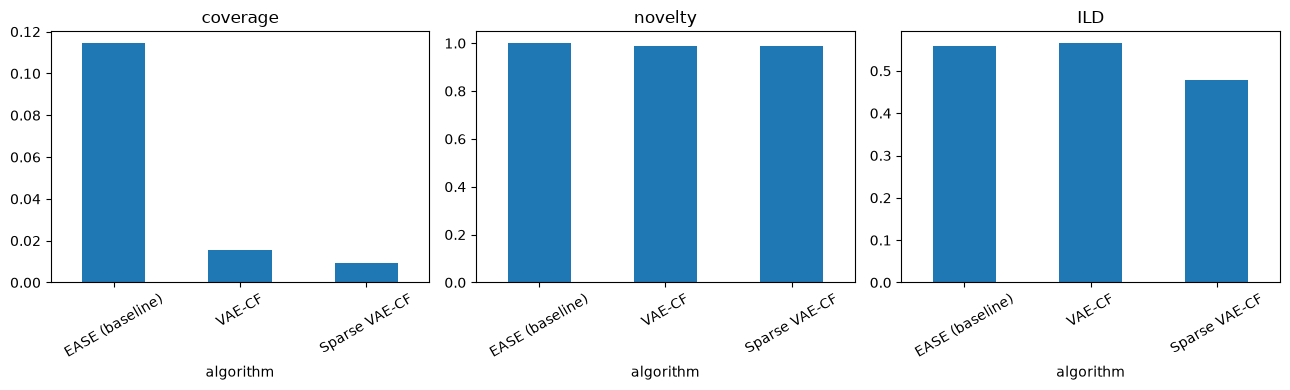

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["coverage", "novelty", "ILD"]):
    metrics_df[col].plot.bar(ax=ax, title=col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()
